# Common

### Import


In [1]:
import ee
import geemap
import rasterio
import sys
import os

sys.path.append('../.')
from matplotlib.colors import LinearSegmentedColormap
from src.export_web_maps import *
from src.preprocessing_heatMap_helper import *

%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\Surface\anaconda3\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Surface\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<froze

### Initialize the Google Earth Engine API

In [2]:
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project= 'ee-nairobi-heatmap')

# Part 1 - Nairobi Heatmap 
This first part of the notebook focus on getting a heatmap of Nairobi. 

### Nairobi boundary
This boudary have been [downloaded](https://data.humdata.org/dataset/cod-ab-ken). The one from the FAO is a bit shifted (NE). But in fact the one from the humdata website is also shifted (NNW).

In [3]:
# this administrative boundary where added by hand into the assets of my GEE project, it also leads to a shift
nairobi_boundary = ee.FeatureCollection("projects/ee-nairobi-heatmap/assets/ken_admin2") \
                    .filter(ee.Filter.eq('adm1_name', 'Nairobi'))

# Here is my original cloud code but it leads to a shift in the boundaries
# nairobi_boundary = ee.FeatureCollection("FAO/GAUL/2015/level2") \
#                     .filter(ee.Filter.eq('ADM2_NAME', 'Nairobi'))

### Map visualisation

Processing LST for 2020...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\lst_geotiffs\LST_2020.tif
Saved: ../results\lst_geotiffs\LST_2020.tif
Processing LST for 2022...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\lst_geotiffs\LST_2022.tif
Saved: ../results\lst_geotiffs\LST_2022.tif
Processing LST for 2024...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\lst_geotiffs\LST_2024.tif
Saved: ../results\lst_geotiffs\LST_2024.tif


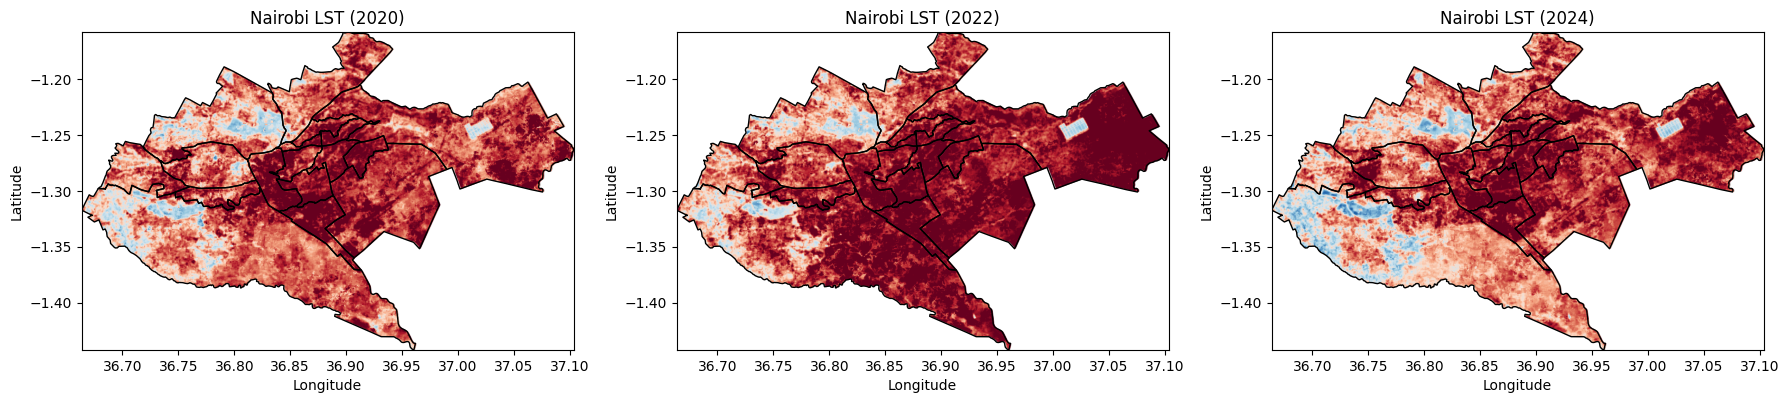

In [4]:
# To plot the Land Surface Temperature and Also download the GeoTIFF maps to 
# show them in the website
fig = heatmap_overyears_of(nairobi_boundary, [2020, 2022, 2024])

### Web export

In [5]:
import os
from src.adaptive_capacity_helper import PROJECT_ROOT
WEBAPP_MAPS = os.path.join(PROJECT_ROOT, 'webapp', 'public', 'maps')

# Blue -> red heat scale (no green), matching the dashboard legend
lst_cmap = LinearSegmentedColormap.from_list("lst", [
    '#053061', '#2166ac', '#4393c3', '#92c5de', '#d1e5f0',
    '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f'])

for year in [2020, 2022, 2024]:
    with rasterio.open(f"../results/lst_geotiffs/LST_{year}.tif") as src:
        lst_array = src.read(1)
        lst_grid = {'bounds': src.bounds, 'crs': src.crs}
    export_raster_for_web(lst_array, lst_grid, f"lst_{year}",
                          cmap=lst_cmap, vmin=20, vmax=40, output_dir=WEBAPP_MAPS)


Exported 'lst_2020' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported 'lst_2022' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported 'lst_2024' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps


### Personal Conclusion
Overall the map seems pretty correct and accurate.

__Problems:__
- holes inside the map which may lead to futur problematic behavior $\rarr$ __solve__ using interpollation (the data was actually missing inside the band I was looking to)
- boudary a shifted to the north of approximatly 300 meters $\rarr$ problematic when layered over a classic map but not wrong  $\rarr$ __solve__ by removing the overlay of my map above the google earth one. 